# EP Leverage Throttle v4 — High-Dimensional State Conditioning

**Macro state variables** (FRED + Yahoo): T10YIE, DFII10, T10Y3M, DXY, SP500 growth  
**Technical state variables** (computed): VIX, VIX term structure, RSI 14, SMA 50 slope, Drawdown  

All partitioned P25/P75 rolling 504d → Lo/Mid/Hi.  
Joint FFR (state & time conditional) → 21d CVaR → expanding percentile rank → leverage 0.5x / 1.0x / 1.5x.  
SMA 200 bear override → 0.0x.  
Signal at t applied at t+1 (no look-ahead bias).

In [24]:
import numpy as np
import pandas as pd
import yfinance as yf
import fortitudo.tech as ft
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
from itertools import product
import warnings
warnings.filterwarnings('ignore')

try:
    from fredapi import Fred
    HAS_FRED = True
except ImportError:
    HAS_FRED = False
    print('fredapi not installed — FRED series will be skipped')

print('Imports OK')

Imports OK


## 1 — Data Fetching & Alignment

In [25]:
# ── Yahoo Finance ─────────────────────────────────────────────────
# DX-Y.NYB often fails — use UUP (dollar bull ETF) as DXY proxy
yahoo_tickers = {'SPY': 'SPY', 'VIX': '^VIX', 'VIX3M': '^VIX3M', 'DXY': 'UUP'}
raw_yahoo = yf.download(list(yahoo_tickers.values()), start='1993-01-01', auto_adjust=True)

# Handle column extraction (yfinance version differences)
if isinstance(raw_yahoo.columns, pd.MultiIndex):
    close = raw_yahoo['Close'].copy()
    ticker_to_name = {v: k for k, v in yahoo_tickers.items()}
    close.columns = [ticker_to_name.get(c, c) for c in close.columns]
else:
    close = raw_yahoo.copy()

# Drop columns that are entirely NaN
close = close.dropna(axis=1, how='all')

# SPY volume
vol_raw = yf.download('SPY', start='1993-01-01', auto_adjust=True)
if isinstance(vol_raw.columns, pd.MultiIndex):
    spy_volume = vol_raw['Volume'].iloc[:, 0]
else:
    spy_volume = vol_raw['Volume']
spy_volume = spy_volume.rename('SPY_Volume')

# ── FMP: S&P 500 historical data (supplementary volume/VWAP) ─────
FMP_KEY = 'AQ7vZFufNFKFggLRz4E8wpBmEETEBcy9'
import requests

fmp_vwap = pd.Series(dtype=float, name='FMP_VWAP')
fmp_volume = pd.Series(dtype=float, name='FMP_Volume')

for ep in [
    'https://financialmodelingprep.com/stable/historical-price-full/SPY?apikey=' + FMP_KEY,
    'https://financialmodelingprep.com/api/v3/historical-price-full/SPY?apikey=' + FMP_KEY,
]:
    try:
        resp = requests.get(ep, timeout=15)
        if resp.status_code != 200:
            print('FMP: HTTP ' + str(resp.status_code))
            continue
        data = resp.json()
        if isinstance(data, dict) and 'historical' in data:
            fmp_hist = pd.DataFrame(data['historical'])
        elif isinstance(data, list) and len(data) > 0:
            fmp_hist = pd.DataFrame(data)
        else:
            continue
        fmp_hist['date'] = pd.to_datetime(fmp_hist['date'])
        fmp_hist = fmp_hist.set_index('date').sort_index()
        if 'vwap' in fmp_hist.columns:
            fmp_vwap = fmp_hist['vwap'].rename('FMP_VWAP')
        elif {'high', 'low', 'close'}.issubset(fmp_hist.columns):
            fmp_vwap = ((fmp_hist['high'] + fmp_hist['low'] + fmp_hist['close']) / 3).rename('FMP_VWAP')
        if 'volume' in fmp_hist.columns:
            fmp_volume = fmp_hist['volume'].rename('FMP_Volume')
        print('FMP: ' + str(len(fmp_hist)) + ' days loaded')
        break
    except Exception as e:
        print('FMP error: ' + str(e))

print('Yahoo close: ' + str(close.index[0].date()) + ' to ' + str(close.index[-1].date()))
print('Columns: ' + str(list(close.columns)))

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


FMP: HTTP 404
FMP: HTTP 403
Yahoo close: 1993-01-04 to 2026-03-17
Columns: ['SPY', 'DXY', 'VIX', 'VIX3M']


In [26]:
# ── FRED Series ───────────────────────────────────────────────────
fred_series = {
    'T10YIE': 'T10YIE',       # 10Y breakeven inflation
    'DFII10': 'DFII10',       # 10Y real interest rate
    'T10Y3M': 'T10Y3M',       # yield curve slope (10Y - 3M)
}

fred_df = pd.DataFrame()
if HAS_FRED:
    fred_key = 'f887507374b463ac1fcc8e0ad01cbed3'
    fred = Fred(api_key=fred_key)
    frames = {}
    for name, sid in fred_series.items():
        try:
            s = fred.get_series(sid, observation_start='1993-01-01')
            frames[name] = s
            print(f'  FRED {sid}: {len(s)} obs')
        except Exception as e:
            print(f'  FRED {sid} failed: {e}')
    if frames:
        fred_df = pd.DataFrame(frames)
        fred_df.index = pd.to_datetime(fred_df.index)
else:
    print('fredapi not available')

print(f'FRED columns: {list(fred_df.columns) if not fred_df.empty else "none"}')

  FRED T10YIE: 6053 obs
  FRED DFII10: 6052 obs
  FRED T10Y3M: 8662 obs
FRED columns: ['T10YIE', 'DFII10', 'T10Y3M']


In [27]:
# ── Merge & Align ────────────────────────────────────────────────
df = close.copy()

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Strip timezone from index if present
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

# Join SPY volume
sv = spy_volume.copy()
if sv.index.tz is not None:
    sv.index = sv.index.tz_localize(None)
df['SPY_Volume'] = sv

# Join FMP data if available
if len(fmp_vwap) > 0:
    df = df.join(fmp_vwap, how='left')
    df['FMP_VWAP'] = df['FMP_VWAP'].ffill()
if len(fmp_volume) > 0:
    df = df.join(fmp_volume, how='left')
    df['FMP_Volume'] = df['FMP_Volume'].ffill()

# Join FRED
if not fred_df.empty:
    fred_tmp = fred_df.copy()
    if fred_tmp.index.tz is not None:
        fred_tmp.index = fred_tmp.index.tz_localize(None)
    df = df.join(fred_tmp, how='left')
    for col in fred_series.keys():
        if col in df.columns:
            df[col] = df[col].ffill()

# Drop non-trading days
df = df.dropna(subset=['SPY'])
print('After SPY dropna: ' + str(len(df)) + ' rows')

# ── Compute derived features ─────────────────────────────────────
df['spy_ret'] = df['SPY'].pct_change()
df['spy_log_ret'] = np.log(df['SPY'] / df['SPY'].shift(1))
df['sp500_growth'] = df['SPY'].pct_change(21)

# DXY stays as level (strong/weak dollar regime) — no pct_change

if 'VIX3M' in df.columns and df['VIX3M'].notna().sum() > 100:
    df['vix_ts'] = df['VIX'] / df['VIX3M']

delta = df['SPY'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14'] = 100 - 100 / (1 + gain / loss)

df['sma_50'] = df['SPY'].rolling(50).mean()
df['sma50_slope'] = df['sma_50'] / df['sma_50'].shift(21) - 1
df['drawdown'] = df['SPY'] / df['SPY'].rolling(252).max() - 1
df['sma_200'] = df['SPY'].rolling(200).mean()

if 'SPY_Volume' in df.columns and df['SPY_Volume'].notna().sum() > 100:
    df['vol_ratio'] = df['SPY_Volume'] / df['SPY_Volume'].rolling(50).mean()

if 'FMP_VWAP' in df.columns and df['FMP_VWAP'].notna().sum() > 100:
    df['price_vs_vwap'] = (df['SPY'] - df['FMP_VWAP']) / df['FMP_VWAP']

# Drop warmup — only core columns
core_cols = ['spy_ret', 'sma_200', 'drawdown', 'rsi_14', 'sma50_slope', 'sp500_growth']
before = len(df)
df = df.dropna(subset=core_cols)
after = len(df)
print('After core dropna: ' + str(after) + ' rows (dropped ' + str(before - after) + ' warmup)')

if len(df) == 0:
    print('ERROR: DataFrame is empty! Check data downloads above.')
else:
    print('Aligned: ' + str(df.index[0].date()) + ' to ' + str(df.index[-1].date()) + ' (' + str(len(df)) + ' days)')
    for col in df.columns:
        nn = df[col].isna().sum()
        if nn > 0:
            pct = str(round(nn / len(df) * 100, 1))
            print('  ' + col + ': ' + str(nn) + ' NaN (' + pct + '%)')

After SPY dropna: 8338 rows
After core dropna: 8087 rows (dropped 251 warmup)
Aligned: 1994-01-26 to 2026-03-16 (8087 days)
  DXY: 3296 NaN (40.8%)
  VIX3M: 3140 NaN (38.8%)
  T10YIE: 2250 NaN (27.8%)
  DFII10: 2250 NaN (27.8%)
  vix_ts: 3140 NaN (38.8%)


## 2 — State Variable Definitions & Configuration

In [28]:
# ── State variable registry ──────────────────────────────────────
# Each entry: (column_name, display_name)
# All use rolling P25/P75 partitioning

STATE_VARS_MACRO = [
    ('sp500_growth',  'SP500 Growth (21d)'),
    ('T10Y3M',        'Yield Curve Slope'),
    ('T10YIE',        'Breakeven Inflation'),
    ('DFII10',        'Real Rate 10Y'),
    ('DXY',           'Dollar Index (level)'),
]

STATE_VARS_TECH = [
    ('VIX',           'VIX Level'),
    ('vix_ts',        'VIX Term Structure'),
    ('rsi_14',        'RSI 14'),
    ('sma50_slope',   'SMA 50 Slope'),
    ('drawdown',      'Drawdown Depth'),
]

STATE_VARS_VOLUME = [
    ('vol_ratio',     'Relative Volume (50d)'),
    ('price_vs_vwap', 'Price vs VWAP'),
]

# Filter to available columns only
ALL_STATE_VARS = []
for col, name in STATE_VARS_MACRO + STATE_VARS_TECH + STATE_VARS_VOLUME:
    if col in df.columns and df[col].notna().sum() > 504:
        ALL_STATE_VARS.append((col, name))
    else:
        print('  SKIPPING ' + name + ' (' + col + ') — insufficient data or not available')

print('')
print('Active state variables (' + str(len(ALL_STATE_VARS)) + '):')
for col, name in ALL_STATE_VARS:
    print('  ' + name.ljust(25) + ' [' + col + ']  — ' + str(df[col].notna().sum()) + ' obs')

  SKIPPING Price vs VWAP (price_vs_vwap) — insufficient data or not available

Active state variables (11):
  SP500 Growth (21d)        [sp500_growth]  — 8087 obs
  Yield Curve Slope         [T10Y3M]  — 8087 obs
  Breakeven Inflation       [T10YIE]  — 5837 obs
  Real Rate 10Y             [DFII10]  — 5837 obs
  Dollar Index (level)      [DXY]  — 4791 obs
  VIX Level                 [VIX]  — 8087 obs
  VIX Term Structure        [vix_ts]  — 4947 obs
  RSI 14                    [rsi_14]  — 8087 obs
  SMA 50 Slope              [sma50_slope]  — 8087 obs
  Drawdown Depth            [drawdown]  — 8087 obs
  Relative Volume (50d)     [vol_ratio]  — 8087 obs


In [29]:
# ── Configuration ────────────────────────────────────────────────
H = 21                          # forward horizon (trading days)
S_SIM = 10_00                  # simulation paths
ALPHA = 0.90                    # CVaR confidence level
TC_BPS = 0.0010                 # transaction cost per leverage change

STATE_WINDOW = 504              # ~2yr rolling window
LO_PCT = 25
HI_PCT = 75

# Three-phase walk-forward
PHASE0_DAYS = 504               # Phase 0: calibration only
PHASE1_DAYS = 504               # Phase 1: CVaR collection, no trading

# Leverage mapping
RANK_LO = 0.25
RANK_HI = 0.75
LEV_STEPS = [1.5, 1.0, 0.5]    # calm / normal / stressed

SEED = 42

N_VARS = len(ALL_STATE_VARS)
N_LEVELS = 3
N_STATES = N_LEVELS ** N_VARS

print(f'H={H}d | Sims={S_SIM:,} | CVaR alpha={ALPHA}')
print(f'State variables: {N_VARS} → {N_LEVELS}^{N_VARS} = {N_STATES} joint states')
print(f'Rolling window: {STATE_WINDOW}d | Phases: {PHASE0_DAYS}d + {PHASE1_DAYS}d + live')
print(f'Leverage bands: rank < {RANK_LO} → {LEV_STEPS[0]}x | '
      f'{RANK_LO}-{RANK_HI} → {LEV_STEPS[1]}x | > {RANK_HI} → {LEV_STEPS[2]}x')

if N_STATES > 100:
    print(f'\n⚠️  {N_STATES} states is very high — EP constraints will be sparse.')
    print(f'    With 504d window: ~{504 // N_STATES} obs/state on average.')
    print(f'    Consider reducing variables or using 2 levels (median split).')

H=21d | Sims=1,000 | CVaR alpha=0.9
State variables: 11 → 3^11 = 177147 joint states
Rolling window: 504d | Phases: 504d + 504d + live
Leverage bands: rank < 0.25 → 1.5x | 0.25-0.75 → 1.0x | > 0.75 → 0.5x

⚠️  177147 states is very high — EP constraints will be sparse.
    With 504d window: ~0 obs/state on average.
    Consider reducing variables or using 2 levels (median split).


## 3 — Rolling State Classification

In [30]:
def classify_single_var(values, lo_pct=LO_PCT, hi_pct=HI_PCT):
    """Classify a single variable into Lo(0)/Mid(1)/Hi(2) using percentiles."""
    p_lo = np.percentile(values, lo_pct)
    p_hi = np.percentile(values, hi_pct)
    levels = np.ones(len(values), dtype=int)  # Mid = 1
    levels[values <= p_lo] = 0                 # Lo = 0
    levels[values > p_hi] = 2                  # Hi = 2
    return levels, p_lo, p_hi


def encode_joint_state(level_vectors):
    """Encode multiple level vectors into a single joint state index.
    
    joint_state = sum(level_k * 3^k for k in range(n_vars))
    """
    n_vars = len(level_vectors)
    n_obs = len(level_vectors[0])
    states = np.zeros(n_obs, dtype=int)
    for k in range(n_vars):
        states += level_vectors[k] * (3 ** k)
    return states


def decode_joint_state(state_idx, n_vars):
    """Decode joint state index back to individual levels."""
    levels = []
    remaining = state_idx
    for k in range(n_vars):
        levels.append(remaining % 3)
        remaining //= 3
    return levels


def joint_state_label(state_idx, var_names, n_vars):
    """Human-readable label for joint state."""
    level_names = ['Lo', 'Mi', 'Hi']
    levels = decode_joint_state(state_idx, n_vars)
    parts = [f'{var_names[k][:3]}={level_names[levels[k]]}' for k in range(n_vars)]
    return '|'.join(parts)


print(f'Example joint state 0: {joint_state_label(0, [n for _, n in ALL_STATE_VARS], N_VARS)}')
print(f'Example joint state {N_STATES-1}: {joint_state_label(N_STATES-1, [n for _, n in ALL_STATE_VARS], N_VARS)}')

Example joint state 0: SP5=Lo|Yie=Lo|Bre=Lo|Rea=Lo|Dol=Lo|VIX=Lo|VIX=Lo|RSI=Lo|SMA=Lo|Dra=Lo|Rel=Lo
Example joint state 177146: SP5=Hi|Yie=Hi|Bre=Hi|Rea=Hi|Dol=Hi|VIX=Hi|VIX=Hi|RSI=Hi|SMA=Hi|Dra=Hi|Rel=Hi


In [31]:
# ── Compute daily joint states using rolling 504d window ─────────
N = len(df)
var_columns = [col for col, _ in ALL_STATE_VARS]
var_names = [name for _, name in ALL_STATE_VARS]

# Pre-extract numpy arrays for speed
var_arrays = {col: df[col].values for col in var_columns}

daily_states = np.full(N, -1, dtype=int)
daily_levels = np.full((N, N_VARS), -1, dtype=int)  # individual levels per variable

for t in range(STATE_WINDOW, N):
    win_start = t - STATE_WINDOW
    win_end = t + 1  # inclusive of t
    
    level_vectors = []
    current_levels = []
    for k, col in enumerate(var_columns):
        vals_win = var_arrays[col][win_start:win_end]
        # Check for NaNs in window
        if np.isnan(vals_win).sum() > len(vals_win) * 0.1:  # >10% NaN → skip
            level_vectors = None
            break
        vals_clean = vals_win[~np.isnan(vals_win)]
        p_lo = np.percentile(vals_clean, LO_PCT)
        p_hi = np.percentile(vals_clean, HI_PCT)
        
        # Classify current day's value
        val_now = var_arrays[col][t]
        if np.isnan(val_now):
            level_vectors = None
            break
        if val_now <= p_lo:
            lvl = 0
        elif val_now > p_hi:
            lvl = 2
        else:
            lvl = 1
        current_levels.append(lvl)
    
    if level_vectors is None or len(current_levels) != N_VARS:
        continue
    
    # Encode joint state
    state = 0
    for k in range(N_VARS):
        state += current_levels[k] * (3 ** k)
    daily_states[t] = state
    daily_levels[t] = current_levels

valid_mask = daily_states >= 0
n_valid = valid_mask.sum()
print(f'Rolling {STATE_WINDOW}d joint states computed for {n_valid} / {N} days')

# Count unique states actually observed
unique_states = np.unique(daily_states[valid_mask])
print(f'Unique joint states observed: {len(unique_states)} / {N_STATES} possible')

# State change frequency
valid_states = daily_states[valid_mask]
n_changes = (np.diff(valid_states) != 0).sum()
print(f'Regime changes: {n_changes} ({n_changes/len(valid_states):.1%} of days)')
print(f'Avg holding period: {len(valid_states)/n_changes:.1f} days')

Rolling 504d joint states computed for 4337 / 8087 days
Unique joint states observed: 2378 / 177147 possible
Regime changes: 3443 (79.4% of days)
Avg holding period: 1.3 days


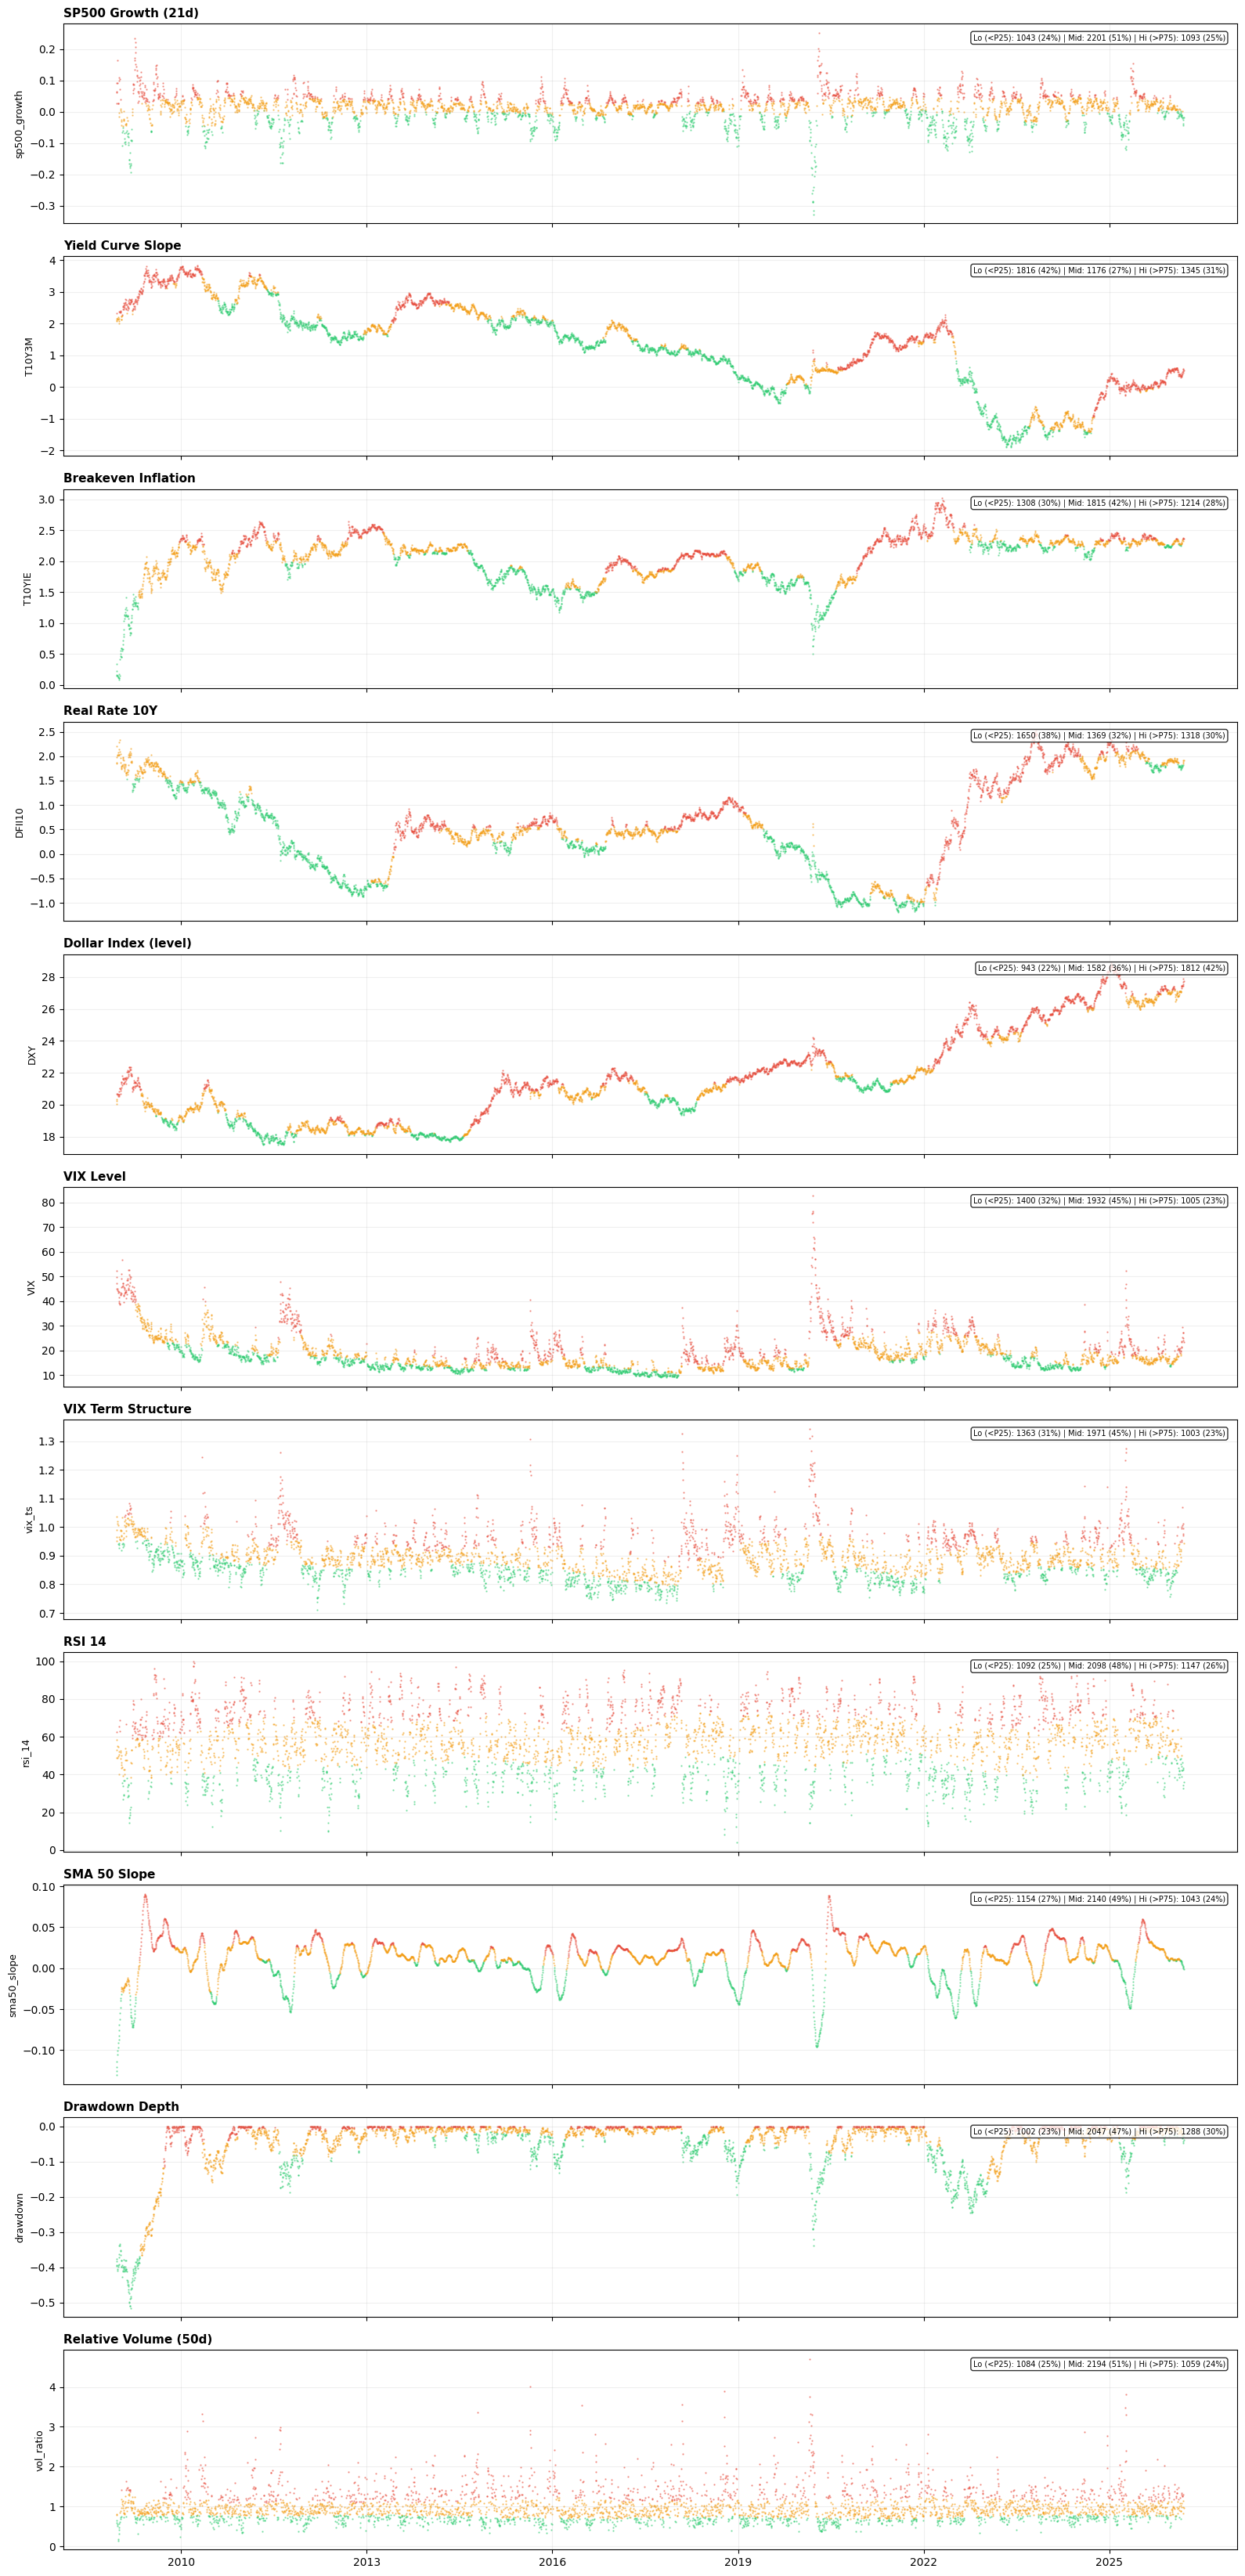

In [32]:
# ── Visualize individual variable partitions ─────────────────────
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
level_labels = ['Lo (<P25)', 'Mid', 'Hi (>P75)']

fig, axes = plt.subplots(N_VARS, 1, figsize=(16, 3 * N_VARS), sharex=True)
if N_VARS == 1:
    axes = [axes]

dates = df.index

for k, (col, name) in enumerate(ALL_STATE_VARS):
    ax = axes[k]
    vals = var_arrays[col]
    lvls = daily_levels[:, k]
    
    for lvl, color in colors_map.items():
        mask = (lvls == lvl) & valid_mask
        ax.scatter(dates[mask], vals[mask], c=color, s=0.5, alpha=0.5, rasterized=True)
    
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(name, fontsize=11, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.2)
    
    counts = [(lvls[valid_mask] == i).sum() for i in range(3)]
    total = sum(counts)
    txt = ' | '.join([f'{level_labels[i]}: {counts[i]} ({counts[i]/total:.0%})' for i in range(3)])
    ax.text(0.99, 0.95, txt, transform=ax.transAxes, fontsize=7, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].xaxis.set_major_locator(mdates.YearLocator(3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4 — EP Engine (High-Dimensional Joint States)

In [33]:
def compute_state_probs_joint(log_returns, var_data_dict, states_vector, n_states):
    """Compute EP state-conditional probability vectors for joint states.
    
    For each joint state: EP with mean equality + variance inequality
    on ALL state variables simultaneously.
    
    Parameters
    ----------
    log_returns : 1d array, SPY log returns (training window)
    var_data_dict : dict of {col_name: 1d array} for each state variable
    states_vector : 1d int array, joint state index per observation
    n_states : int, total number of possible joint states
    
    Returns
    -------
    states_prob : (T, n_states) array of probability vectors
    ens_per_state : dict of ENS values per state
    """
    T = len(log_returns)
    ret_df = pd.DataFrame(log_returns, columns=['SPY'])
    p_exp = ft.exp_decay_probs(ret_df, half_life=T / 2)
    
    var_names = list(var_data_dict.keys())
    var_arrays_local = [var_data_dict[v] for v in var_names]
    n_vars_local = len(var_names)
    
    states_prob = np.zeros((T, n_states))
    ens_per_state = {}
    
    for state in range(n_states):
        mask = states_vector == state
        n_obs = mask.sum()
        
        if n_obs < max(10, 2 * n_vars_local):
            # Too few observations — fallback to prior
            states_prob[:, state] = p_exp[:, 0]
            ens_per_state[state] = 100.0
            continue
        
        # Build equality constraints: sum=1 + mean per variable
        A_rows = [np.ones((1, T))]  # sum(p) = 1
        b_vals = [1.0]
        
        # Build inequality constraints: variance per variable
        G_rows = []
        h_vals = []
        
        for v_arr in var_arrays_local:
            mu = np.mean(v_arr[mask])
            sigma = np.std(v_arr[mask])
            
            A_rows.append(v_arr[np.newaxis, :])
            b_vals.append(mu)
            
            G_rows.append((v_arr ** 2)[np.newaxis, :])
            h_vals.append(sigma ** 2 + mu ** 2)
        
        A = np.vstack(A_rows)
        b = np.array(b_vals).reshape(-1, 1)
        G = np.vstack(G_rows)
        h = np.array(h_vals).reshape(-1, 1)
        
        try:
            q = ft.entropy_pooling(p_exp, A, b, G, h)
            states_prob[:, state] = q[:, 0]
            
            # ENS
            re = float(q.T @ (np.log(q + 1e-30) - np.log(p_exp + 1e-30)))
            ens = np.exp(-re) * 100
            ens_per_state[state] = ens
        except Exception:
            states_prob[:, state] = p_exp[:, 0]
            ens_per_state[state] = 100.0
    
    return states_prob, ens_per_state


def resample_paths(S, H, initial_state, states_prob, states_vector, log_returns):
    """FFR: simulate S paths of H days with state-dependent transitions."""
    T = len(log_returns)
    t_indices = np.arange(T)
    sim_returns = np.zeros((S, H))
    
    for s in range(S):
        current_state = initial_state
        for h_step in range(H):
            p_state = states_prob[:, current_state].copy()
            p_state = np.maximum(p_state, 0)
            p_sum = p_state.sum()
            if p_sum <= 0:
                p_state = np.ones(T) / T
            else:
                p_state /= p_sum
            idx = np.random.choice(t_indices, p=p_state)
            sim_returns[s, h_step] = log_returns[idx]
            current_state = states_vector[idx]
    
    return sim_returns.sum(axis=1)  # H-day cumulative log return


def compute_cvar(returns, alpha=ALPHA):
    """CVaR (expected shortfall) at given confidence level."""
    threshold = np.percentile(returns, (1 - alpha) * 100)
    tail = returns[returns <= threshold]
    return -tail.mean() if len(tail) > 0 else 0.0


def cvar_percentile_rank(cvar_val, cvar_history):
    """Expanding percentile rank of CVaR within history."""
    recent = np.array(cvar_history)
    n = len(recent)
    if n < 2:
        return 0.5
    below = np.sum(recent < cvar_val)
    equal = np.sum(recent == cvar_val)
    return (below + 0.5 * equal) / n


print(f'EP engine defined. Handles up to {N_STATES} joint states with {N_VARS} variables.')

EP engine defined. Handles up to 177147 joint states with 11 variables.


## 5 — Three-Phase Walk-Forward Backtest

In [34]:
np.random.seed(SEED)

all_dates = df.index.tolist()

# Adjust phase starts to account for STATE_WINDOW warmup
phase1_start = max(STATE_WINDOW, PHASE0_DAYS)
phase2_start = phase1_start + PHASE1_DAYS

print(f'Dataset: {N} days ({all_dates[0].date()} -> {all_dates[-1].date()})')
print(f'Phase 0 (calibration): idx 0-{phase1_start-1} ({all_dates[0].date()} -> {all_dates[phase1_start-1].date()})')
print(f'Phase 1 (CVaR collect): idx {phase1_start}-{phase2_start-1} ({all_dates[phase1_start].date()} -> {all_dates[phase2_start-1].date()})')
print(f'Phase 2 (live eval):    idx {phase2_start}-{N-1} ({all_dates[phase2_start].date()} -> {all_dates[-1].date()})')

Dataset: 8087 days (1994-01-26 -> 2026-03-16)
Phase 0 (calibration): idx 0-503 (1994-01-26 -> 1996-01-24)
Phase 1 (CVaR collect): idx 504-1007 (1996-01-25 -> 1998-01-22)
Phase 2 (live eval):    idx 1008-8086 (1998-01-23 -> 2026-03-16)


In [35]:
# ── Phase 1: CVaR Collection ─────────────────────────────────────
print(f'=== Phase 1: CVaR Collection ===')

ffr_records = []
cvar_history = []

prev_state = daily_states[phase1_start - 1] if daily_states[phase1_start - 1] >= 0 else 0
ffr_count = 0
spy_log_ret = df['spy_log_ret'].values

for t in range(phase1_start, phase2_start):
    current_state = daily_states[t]
    if current_state < 0:
        continue  # skip days with missing state
    
    if current_state != prev_state:
        # Rolling 504d window for EP training (aligned)
        win_start = max(0, t + 1 - STATE_WINDOW)
        win_end = t + 1
        
        log_ret_train = spy_log_ret[win_start:win_end]
        
        # Build variable data dict for training window
        var_data = {col: var_arrays[col][win_start:win_end] for col in var_columns}
        
        # Classify training window into joint states
        level_vecs = []
        for col in var_columns:
            vals = var_data[col]
            vals_clean = vals[~np.isnan(vals)]
            if len(vals_clean) < 50:
                break
            lvl, _, _ = classify_single_var(vals_clean)
            # Reclassify full window (including NaN positions as Mid)
            full_lvl = np.ones(len(vals), dtype=int)
            p_lo = np.percentile(vals_clean, LO_PCT)
            p_hi = np.percentile(vals_clean, HI_PCT)
            nan_mask = ~np.isnan(vals)
            full_lvl[nan_mask & (vals <= p_lo)] = 0
            full_lvl[nan_mask & (vals > p_hi)] = 2
            level_vecs.append(full_lvl)
        
        if len(level_vecs) != N_VARS:
            prev_state = current_state
            continue
        
        states_vec = encode_joint_state(level_vecs)
        
        # Compute EP probabilities
        states_prob, ens = compute_state_probs_joint(
            log_ret_train, var_data, states_vec, N_STATES)
        
        # FFR from current state
        cum_returns = resample_paths(S_SIM, H, current_state, states_prob, states_vec, log_ret_train)
        cvar_val = compute_cvar(cum_returns, ALPHA)
        cvar_history.append(cvar_val)
        ffr_count += 1
        
        ffr_records.append({
            'date': all_dates[t], 'idx': t, 'phase': 'collection',
            'state': current_state, 'cvar': cvar_val, 'rank': np.nan,
            'vix': df['VIX'].iloc[t],
            'sma_bear': df['SPY'].iloc[t] < df['sma_200'].iloc[t],
        })
        
        if ffr_count % 20 == 0:
            print(f'  FFR #{ffr_count} | {all_dates[t].date()} | '
                  f'state {prev_state}->{current_state} | CVaR={cvar_val:.4f}')
    
    prev_state = current_state

print(f'Phase 1 complete: {ffr_count} FFR runs → {len(cvar_history)} CVaR obs')
if cvar_history:
    print(f'CVaR range: [{min(cvar_history):.4f}, {max(cvar_history):.4f}]')

=== Phase 1: CVaR Collection ===
Phase 1 complete: 0 FFR runs → 0 CVaR obs


In [36]:
# ── Phase 2: Live Evaluation ─────────────────────────────────────
print(f'=== Phase 2: Live Evaluation ===')

prev_state = daily_states[phase2_start - 1] if daily_states[phase2_start - 1] >= 0 else 0
ffr_count_eval = 0

for t in range(phase2_start, N):
    current_state = daily_states[t]
    if current_state < 0:
        continue
    
    if current_state != prev_state:
        win_start = max(0, t + 1 - STATE_WINDOW)
        win_end = t + 1
        
        log_ret_train = spy_log_ret[win_start:win_end]
        var_data = {col: var_arrays[col][win_start:win_end] for col in var_columns}
        
        level_vecs = []
        for col in var_columns:
            vals = var_data[col]
            vals_clean = vals[~np.isnan(vals)]
            if len(vals_clean) < 50:
                break
            p_lo = np.percentile(vals_clean, LO_PCT)
            p_hi = np.percentile(vals_clean, HI_PCT)
            full_lvl = np.ones(len(vals), dtype=int)
            nan_mask = ~np.isnan(vals)
            full_lvl[nan_mask & (vals <= p_lo)] = 0
            full_lvl[nan_mask & (vals > p_hi)] = 2
            level_vecs.append(full_lvl)
        
        if len(level_vecs) != N_VARS:
            prev_state = current_state
            continue
        
        states_vec = encode_joint_state(level_vecs)
        states_prob, ens = compute_state_probs_joint(
            log_ret_train, var_data, states_vec, N_STATES)
        
        cum_returns = resample_paths(S_SIM, H, current_state, states_prob, states_vec, log_ret_train)
        cvar_val = compute_cvar(cum_returns, ALPHA)
        cvar_history.append(cvar_val)
        
        rank = cvar_percentile_rank(cvar_val, cvar_history)
        ffr_count_eval += 1
        
        ffr_records.append({
            'date': all_dates[t], 'idx': t, 'phase': 'eval',
            'state': current_state, 'cvar': cvar_val, 'rank': rank,
            'vix': df['VIX'].iloc[t],
            'sma_bear': df['SPY'].iloc[t] < df['sma_200'].iloc[t],
        })
        
        if ffr_count_eval % 100 == 0:
            print(f'  Eval FFR #{ffr_count_eval} | {all_dates[t].date()} | '
                  f'state {prev_state}->{current_state} | '
                  f'CVaR={cvar_val:.4f} | rank={rank:.2f} | pool={len(cvar_history)}')
    
    prev_state = current_state

rebal_df = pd.DataFrame(ffr_records).set_index('date')
print(f'\nDone. {len(rebal_df)} total FFR runs ({len(cvar_history)} CVaR obs).')
print(f'  Phase 1: {ffr_count} collection | Phase 2: {ffr_count_eval} eval triggers')

=== Phase 2: Live Evaluation ===
  Eval FFR #100 | 2009-07-01 | state 94408->35359 | CVaR=0.1944 | rank=0.01 | pool=100
  Eval FFR #200 | 2010-01-21 | state 166319->173608 | CVaR=0.1683 | rank=0.10 | pool=200
  Eval FFR #300 | 2010-08-06 | state 30713->89678 | CVaR=0.1565 | rank=0.23 | pool=300
  Eval FFR #400 | 2011-02-07 | state 107215->107944 | CVaR=0.0835 | rank=0.04 | pool=400
  Eval FFR #500 | 2011-08-01 | state 139743->139500 | CVaR=0.0682 | rank=0.11 | pool=500
  Eval FFR #600 | 2012-02-08 | state 116732->116975 | CVaR=0.0958 | rank=0.25 | pool=600
  Eval FFR #700 | 2012-08-06 | state 87571->28522 | CVaR=0.0862 | rank=0.19 | pool=700
  Eval FFR #800 | 2013-01-18 | state 109454->168502 | CVaR=0.0810 | rank=0.18 | pool=800
  Eval FFR #900 | 2013-07-12 | state 110221->51173 | CVaR=0.0643 | rank=0.02 | pool=900
  Eval FFR #1000 | 2014-01-16 | state 107234->28501 | CVaR=0.0439 | rank=0.03 | pool=1000
  Eval FFR #1100 | 2014-07-09 | state 147298->88249 | CVaR=0.0370 | rank=0.00 | poo

## 6 — Percentile Rank → Leverage

In [37]:
def rank_to_leverage(rank, sma_bear):
    """Map CVaR percentile rank to leverage. SMA bear → 0.0x."""
    if sma_bear:
        return 0.0
    if rank < RANK_LO:
        return LEV_STEPS[0]  # 1.5x — calm
    elif rank < RANK_HI:
        return LEV_STEPS[1]  # 1.0x — normal
    else:
        return LEV_STEPS[2]  # 0.5x — stressed


eval_start_date = all_dates[phase2_start]
eval_dates = df.index[df.index >= eval_start_date]
eval_ffr = rebal_df[rebal_df['phase'] == 'eval'].copy()

# Build daily rank: forward-fill, t+1 execution delay (NO LOOK-AHEAD)
daily_rank = pd.Series(np.nan, index=eval_dates)
daily_cvar = pd.Series(np.nan, index=eval_dates)
daily_rank.iloc[0] = 0.5  # neutral start
daily_cvar.iloc[0] = np.median(cvar_history) if cvar_history else 0.0

for date in eval_ffr.index:
    if date in daily_rank.index:
        date_pos = daily_rank.index.get_loc(date)
        if date_pos + 1 < len(daily_rank):
            next_date = daily_rank.index[date_pos + 1]
            daily_rank.loc[next_date] = eval_ffr.loc[date, 'rank']
            daily_cvar.loc[next_date] = eval_ffr.loc[date, 'cvar']

daily_rank = daily_rank.ffill()
daily_cvar = daily_cvar.ffill()

# SMA bear filter (t-1 close vs t-1 SMA — known at open of t)
daily_sma_bear = df['SPY'].shift(1) < df['sma_200'].shift(1)
daily_sma_bear = daily_sma_bear.reindex(eval_dates).fillna(False)

daily_leverage = pd.Series(
    [rank_to_leverage(r, sma) for r, sma in zip(daily_rank, daily_sma_bear)],
    index=eval_dates)

print(f'Evaluation: {eval_dates[0].date()} to {eval_dates[-1].date()} ({len(eval_dates)} days)')
print(f'BIAS CHECK: FFR signal delayed by 1 day (t->t+1), SMA uses t-1 close')
print(f'\nLeverage distribution:')
for lev in sorted(daily_leverage.unique()):
    n = (daily_leverage == lev).sum()
    print(f'  {lev:.1f}x: {n:5d} days ({n/len(daily_leverage):.1%})')

avg_leverage = daily_leverage.mean()
n_lev_changes = (daily_leverage.diff().abs() > 0).sum()
print(f'\nAvg leverage: {avg_leverage:.3f}x | Leverage changes: {n_lev_changes}')

Evaluation: 1998-01-23 to 2026-03-16 (7079 days)
BIAS CHECK: FFR signal delayed by 1 day (t->t+1), SMA uses t-1 close

Leverage distribution:
  0.0x:  1770 days (25.0%)
  0.5x:   294 days (4.2%)
  1.0x:  3314 days (46.8%)
  1.5x:  1701 days (24.0%)

Avg leverage: 0.849x | Leverage changes: 431


## 7 — Backtest

In [38]:
eval_df = df.loc[eval_dates[0]:].copy()

def run_backtest(leverage_series, name):
    equity = 1.0
    prev_lev = 0.0
    records = []
    for date in eval_df.index:
        lev = leverage_series.get(date, prev_lev)
        tc = TC_BPS * abs(lev - prev_lev) * equity if lev != prev_lev else 0.0
        equity -= tc
        ret = eval_df.loc[date, 'spy_ret']
        equity *= (1 + lev * ret)
        records.append({'date': date, 'leverage': lev, 'equity': equity,
                        'daily_ret': lev * ret, 'tc': tc})
        prev_lev = lev
    return pd.DataFrame(records).set_index('date')


bt_ep4 = run_backtest(daily_leverage, 'EP Throttle v4')

sma_lev = pd.Series(1.0, index=eval_df.index)
sma_lev[eval_df['SPY'].shift(1) < eval_df['sma_200'].shift(1)] = 0.0
bt_sma = run_backtest(sma_lev, 'SMA-Only 1.0x')

bh_lev = pd.Series(1.0, index=eval_df.index)
bt_bh = run_backtest(bh_lev, 'SPY B&H 1.0x')

const_avg_lev = pd.Series(avg_leverage, index=eval_df.index)
bt_avg = run_backtest(const_avg_lev, f'B&H {avg_leverage:.2f}x')

strats = {
    'EP Throttle v4': bt_ep4,
    'SMA-Only 1.0x': bt_sma,
    'SPY B&H 1.0x': bt_bh,
    f'B&H {avg_leverage:.2f}x': bt_avg,
}

print('Backtests computed.')

Backtests computed.


## 8 — Performance Metrics

In [39]:
def calc_metrics(bt, name):
    n_years = len(bt) / 252
    total_ret = bt['equity'].iloc[-1] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1
    ann_vol = bt['daily_ret'].std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    dd = ((bt['equity'] - bt['equity'].cummax()) / bt['equity'].cummax()).min()
    calmar = ann_ret / abs(dd) if dd != 0 else 0
    total_tc = bt['tc'].sum()
    ann_tc_bps = (total_tc / n_years) * 10000
    avg_lev = bt['leverage'].mean()
    n_changes = (bt['leverage'].diff().abs() > 0).sum()
    return {
        'Strategy': name,
        'Ann. Return': f'{ann_ret:.2%}',
        'Ann. Vol': f'{ann_vol:.2%}',
        'Sharpe': f'{sharpe:.2f}',
        'Max DD': f'{dd:.2%}',
        'Calmar': f'{calmar:.2f}',
        'Avg Lev': f'{avg_lev:.2f}',
        'Ann. TC (bps)': f'{ann_tc_bps:.0f}',
        'Lev Changes': n_changes,
    }

tbl = pd.DataFrame([calc_metrics(bt, name) for name, bt in strats.items()]).set_index('Strategy')
print('=== Performance (net of TC) ===')
print(tbl.to_string())

=== Performance (net of TC) ===
               Ann. Return Ann. Vol Sharpe   Max DD Calmar Avg Lev Ann. TC (bps)  Lev Changes
Strategy                                                                                     
EP Throttle v4       6.28%   13.57%   0.46  -30.82%   0.20    0.85           251          431
SMA-Only 1.0x        6.30%   11.93%   0.53  -30.82%   0.20    0.75           122          192
SPY B&H 1.0x         9.02%   19.41%   0.46  -55.19%   0.16    1.00             0            0
B&H 0.85x            7.87%   16.48%   0.48  -48.76%   0.16    0.85             0            0


## 9 — Equity Curves & Drawdowns

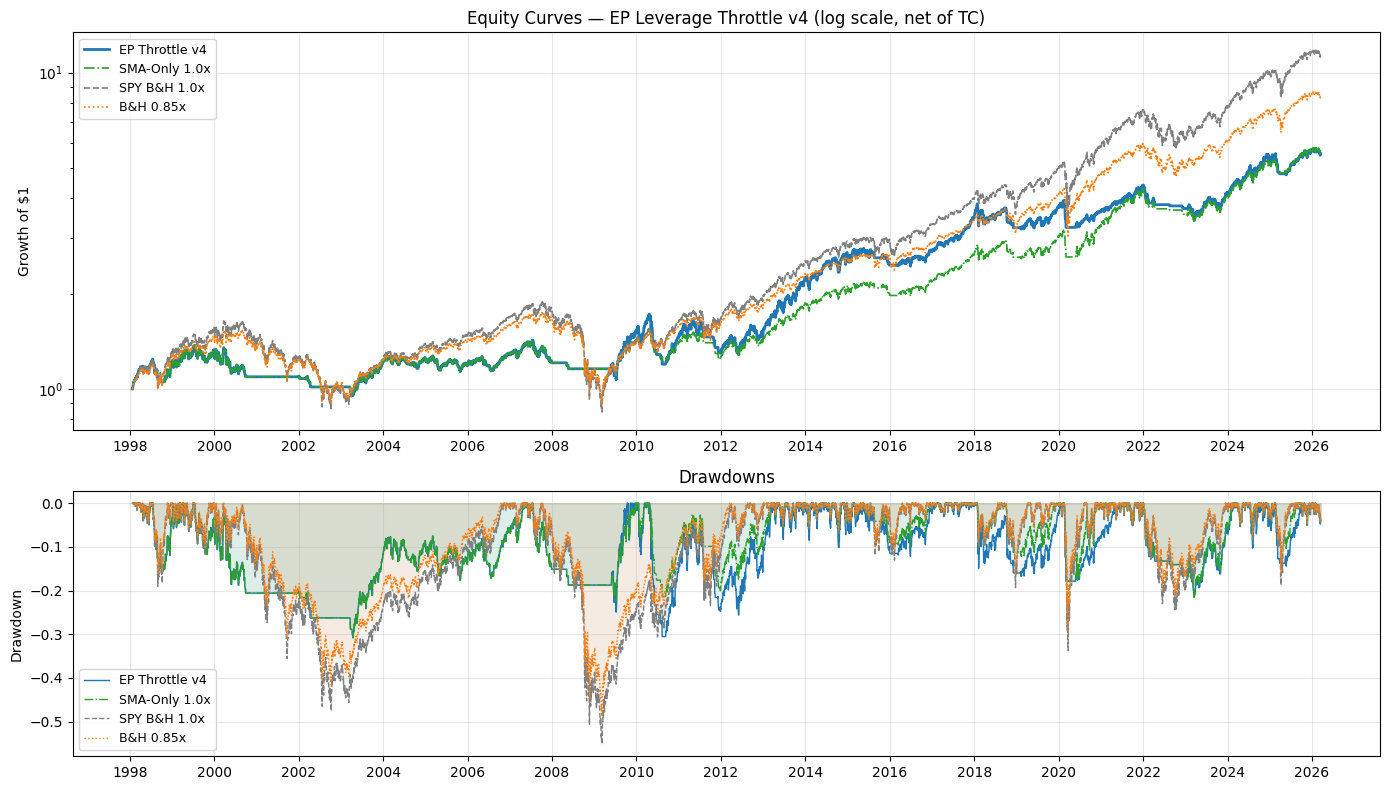

In [40]:
PLOT_STYLES = {
    'EP Throttle v4':   dict(lw=2.0, color='C0', ls='-'),
    'SMA-Only 1.0x':    dict(lw=1.2, color='C2', ls='-.'),
    'SPY B&H 1.0x':     dict(lw=1.2, color='grey', ls='--'),
}
avg_key = f'B&H {avg_leverage:.2f}x'
PLOT_STYLES[avg_key] = dict(lw=1.2, color='C1', ls=':')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 2]})

ax = axes[0]
for name, bt in strats.items():
    s = PLOT_STYLES[name]
    ax.plot(bt.index, bt['equity'], label=name, **s)
ax.set_yscale('log')
ax.set_title('Equity Curves — EP Leverage Throttle v4 (log scale, net of TC)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, bt in strats.items():
    s = PLOT_STYLES[name]
    dd = (bt['equity'] - bt['equity'].cummax()) / bt['equity'].cummax()
    ax.fill_between(bt.index, dd, 0, alpha=0.08, color=s['color'])
    ax.plot(bt.index, dd, label=name, linewidth=1, linestyle=s['ls'], color=s['color'])
ax.set_title('Drawdowns')
ax.set_ylabel('Drawdown')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 10 — Diagnostics

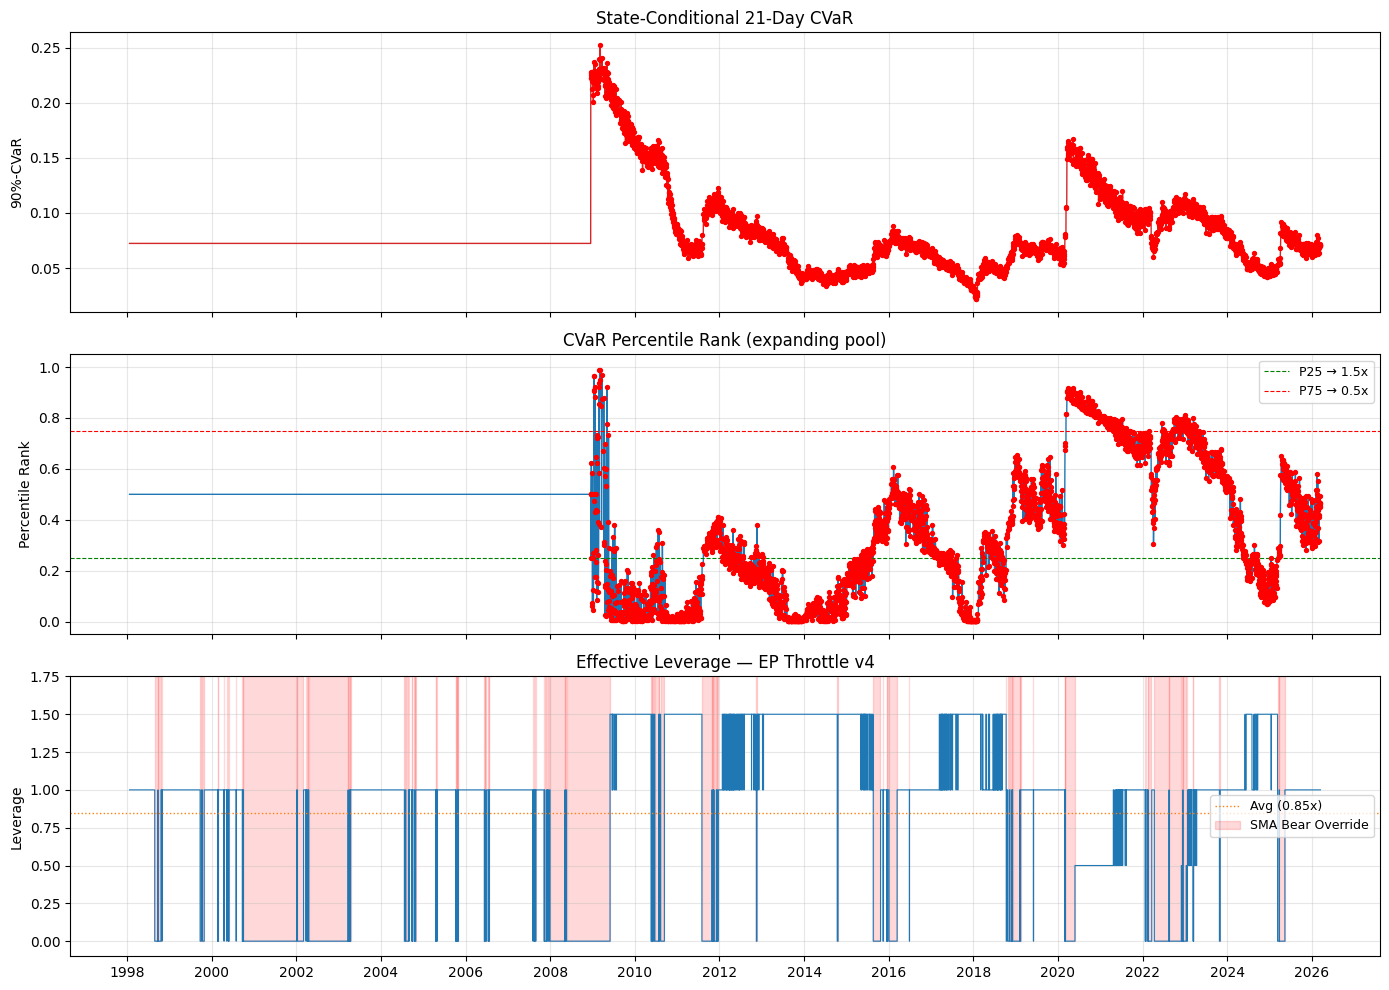

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# CVaR over time
ax = axes[0]
ax.plot(daily_cvar.index, daily_cvar, lw=1, color='C3')
if len(eval_ffr) > 0:
    ax.scatter(eval_ffr.index, eval_ffr['cvar'], color='red', s=8, zorder=5)
ax.set_ylabel(f'{int(ALPHA*100)}%-CVaR')
ax.set_title(f'State-Conditional {H}-Day CVaR')
ax.grid(True, alpha=0.3)

# Percentile rank
ax = axes[1]
ax.plot(daily_rank.index, daily_rank, lw=1, color='C0')
ax.axhline(RANK_LO, color='green', ls='--', lw=0.8, label=f'P{int(RANK_LO*100)} → {LEV_STEPS[0]}x')
ax.axhline(RANK_HI, color='red', ls='--', lw=0.8, label=f'P{int(RANK_HI*100)} → {LEV_STEPS[2]}x')
if len(eval_ffr) > 0:
    ax.scatter(eval_ffr.index, eval_ffr['rank'], color='red', s=8, zorder=5)
ax.set_ylabel('Percentile Rank')
ax.set_ylim(-0.05, 1.05)
ax.set_title('CVaR Percentile Rank (expanding pool)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Leverage
ax = axes[2]
ax.step(daily_leverage.index, daily_leverage.values, where='post', lw=0.8, color='C0')
ax.axhline(avg_leverage, color='C1', ls=':', lw=1, label=f'Avg ({avg_leverage:.2f}x)')
ax.fill_between(daily_leverage.index, 0, 1.75,
                where=daily_sma_bear, alpha=0.15, color='red', label='SMA Bear Override')
ax.set_ylabel('Leverage')
ax.set_title('Effective Leverage — EP Throttle v4')
ax.set_ylim(-0.1, 1.75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 11 — Crisis Analysis

In [42]:
crises = [
    ('Dot-com crash', '2000-03-24', '2002-10-09'),
    ('GFC',           '2007-10-09', '2009-03-09'),
    ('COVID',         '2020-02-19', '2020-03-23'),
    ('2022 Bear',     '2022-01-03', '2022-10-12'),
    ('2018 Q4',       '2018-09-20', '2018-12-24'),
]

crisis_rows = []
for crisis, start, end in crises:
    row = {'Crisis': crisis}
    for name, bt in strats.items():
        sub = bt[(bt.index >= start) & (bt.index <= end)]
        if len(sub) > 0:
            dd = ((sub['equity'] - sub['equity'].cummax()) / sub['equity'].cummax()).min()
            row[name] = f'{dd:.2%}'
        else:
            row[name] = 'N/A'
    crisis_rows.append(row)

crisis_df = pd.DataFrame(crisis_rows).set_index('Crisis')
print('=== Crisis Drawdowns ===')
print(crisis_df.to_string())

=== Crisis Drawdowns ===
              EP Throttle v4 SMA-Only 1.0x SPY B&H 1.0x B&H 0.85x
Crisis                                                           
Dot-com crash        -24.94%       -24.94%      -47.52%   -41.64%
GFC                  -15.09%       -15.09%      -55.19%   -48.76%
COVID                -17.84%       -17.84%      -33.72%   -29.21%
2022 Bear            -14.06%       -14.06%      -24.50%   -21.00%
2018 Q4              -13.53%       -11.31%      -19.35%   -16.63%


## 12 — State Variable Correlation Matrix

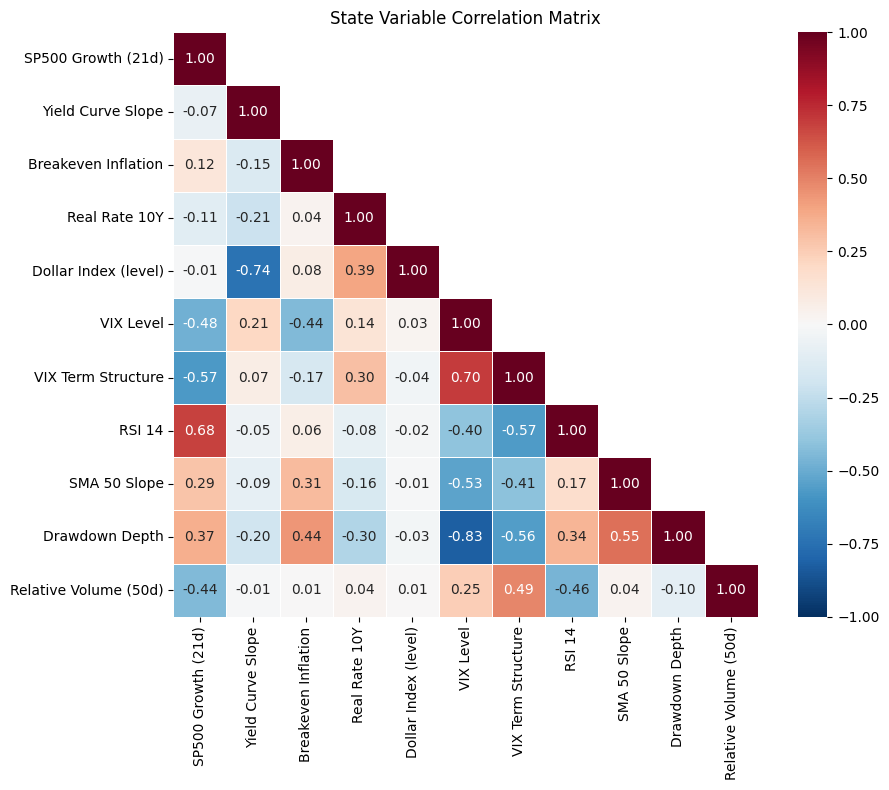


Highly correlated pairs (|r| > 0.7):
  Yield Curve Slope x Dollar Index (level): r=-0.738
  VIX Level x Drawdown Depth: r=-0.825


In [43]:
# Correlation among state variables — check for redundancy
state_var_df = df[var_columns].dropna()
corr = state_var_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=[n for _, n in ALL_STATE_VARS],
            yticklabels=[n for _, n in ALL_STATE_VARS],
            ax=ax)
ax.set_title('State Variable Correlation Matrix')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.7)
print('\nHighly correlated pairs (|r| > 0.7):')
found = False
for i in range(len(var_columns)):
    for j in range(i+1, len(var_columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {ALL_STATE_VARS[i][1]} x {ALL_STATE_VARS[j][1]}: r={r:.3f}')
            found = True
if not found:
    print('  None')

## 13 — CVaR Pool Diagnostics

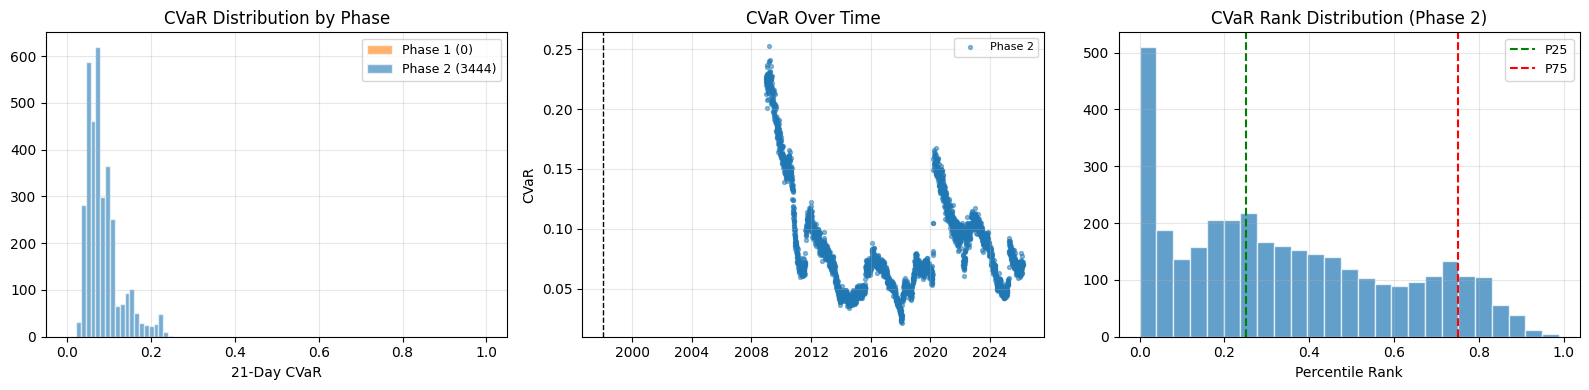

Total CVaR pool: 3444 obs
Phase 2 rank → leverage:
  < P25 (1.5x): 42.2%
  P25-P75 (1.0x): 48.3%
  >= P75 (0.5x): 9.5%


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

collection_cvars = rebal_df[rebal_df['phase'] == 'collection']['cvar']
eval_cvars = rebal_df[rebal_df['phase'] == 'eval']['cvar']

ax = axes[0]
ax.hist(collection_cvars, bins=20, alpha=0.6, color='C1', edgecolor='white',
        label=f'Phase 1 ({len(collection_cvars)})')
ax.hist(eval_cvars, bins=20, alpha=0.6, color='C0', edgecolor='white',
        label=f'Phase 2 ({len(eval_cvars)})')
ax.set_xlabel(f'{H}-Day CVaR')
ax.set_title('CVaR Distribution by Phase')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
if len(collection_cvars) > 0:
    ax.scatter(collection_cvars.index, collection_cvars, s=8, color='C1', alpha=0.5, label='Phase 1')
if len(eval_cvars) > 0:
    ax.scatter(eval_cvars.index, eval_cvars, s=8, color='C0', alpha=0.5, label='Phase 2')
ax.axvline(all_dates[phase2_start], color='black', ls='--', lw=1)
ax.set_ylabel('CVaR')
ax.set_title('CVaR Over Time')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
eval_ranks = eval_ffr['rank'].dropna()
if len(eval_ranks) > 0:
    ax.hist(eval_ranks, bins=25, color='C0', alpha=0.7, edgecolor='white')
ax.axvline(RANK_LO, color='green', ls='--', lw=1.5, label=f'P{int(RANK_LO*100)}')
ax.axvline(RANK_HI, color='red', ls='--', lw=1.5, label=f'P{int(RANK_HI*100)}')
ax.set_xlabel('Percentile Rank')
ax.set_title('CVaR Rank Distribution (Phase 2)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Total CVaR pool: {len(cvar_history)} obs')
if len(eval_ranks) > 0:
    print(f'Phase 2 rank → leverage:')
    print(f'  < P{int(RANK_LO*100)} (1.5x): {(eval_ranks < RANK_LO).mean():.1%}')
    print(f'  P{int(RANK_LO*100)}-P{int(RANK_HI*100)} (1.0x): {((eval_ranks >= RANK_LO) & (eval_ranks < RANK_HI)).mean():.1%}')
    print(f'  >= P{int(RANK_HI*100)} (0.5x): {(eval_ranks >= RANK_HI).mean():.1%}')

## 14 — State Sparsity Analysis

In [45]:
# How many observations per joint state in a typical 504d window?
# This tells us if the high-dimensional state space is tractable.

# Check at a few sample dates
sample_dates_idx = [phase2_start, (phase2_start + N) // 2, N - 1]

for t_check in sample_dates_idx:
    win_start = max(0, t_check + 1 - STATE_WINDOW)
    win_end = t_check + 1
    
    states_win = daily_states[win_start:win_end]
    valid_win = states_win[states_win >= 0]
    
    unique, counts = np.unique(valid_win, return_counts=True)
    
    print(f'\nDate: {all_dates[t_check].date()} | Window: {len(valid_win)} obs | '
          f'Active states: {len(unique)}/{N_STATES}')
    
    if len(counts) > 0:
        print(f'  Obs per state: min={counts.min()}, median={np.median(counts):.0f}, '
              f'max={counts.max()}, mean={counts.mean():.1f}')
        thin = (counts < 10).sum()
        empty = N_STATES - len(unique)
        print(f'  Empty states: {empty} | Thin (<10 obs): {thin} | '
              f'EP-viable (≥10 obs): {len(unique) - thin}')


Date: 1998-01-23 | Window: 0 obs | Active states: 0/177147

Date: 2012-02-15 | Window: 504 obs | Active states: 287/177147
  Obs per state: min=1, median=1, max=11, mean=1.8
  Empty states: 176860 | Thin (<10 obs): 286 | EP-viable (≥10 obs): 1

Date: 2026-03-16 | Window: 504 obs | Active states: 350/177147
  Obs per state: min=1, median=1, max=14, mean=1.4
  Empty states: 176797 | Thin (<10 obs): 349 | EP-viable (≥10 obs): 1
